<a href="https://colab.research.google.com/github/mmurker/LightGBM-Algoritmas-ile-Sistem-Marjinal-Fiyat-Tahmini/blob/main/LightGBM_Algorithm_for_Estimating_System_Marginal_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#TGT AŞAMASI
#HTTP isteği oluşturmak için requests modülünü içe aktaralım.
#Şeffaflık platformundan alacağımız veriler için EPİAŞ Şeffaflık Web Servis Kullanım Kılavuzunun detaylarını incelemenizi tavsiye ederim.
#Web Servis Kullanım Kılavuzu Link: https://seffaflik.epias.com.tr/documentation/web-service-user-guide

import requests
# Kullanıcı bilgileri (değiştirin) EPİAŞ Şeffaflık platformunda oluşturduğumuz kullanıcı adı ve şifre ile sisteme giriş yapmış olacağız.
username = "EPİAŞ Şeffaflık Platformunda Kayıtlı Olan Kullanıcı Adınız!"
password = "EPİAŞ Şeffaflık Platformunda Kayıtlı Olan Şifreniz!"

# 1. TGT Al EPİAŞ Web Servis Kullanım Kılavuzunda gösterildiği gibi TGT almış olacağız.
#Her yeni kod dizininde tekrar etmeniz gerekmez, yalnızca bir kez almak yeterli olacaktır.
auth_url = "https://giris.epias.com.tr/cas/v1/tickets"
headers_auth = {
    "Content-Type": "application/x-www-form-urlencoded",
    "Accept": "text/plain"
}

data_auth = f"username={username}&password={password}"

auth_response = requests.post(auth_url, headers=headers_auth, data=data_auth,timeout=10)

if auth_response.status_code == 201:
    tgt = auth_response.text.strip()
    print("✅ TGT alındı:\n", tgt)
else:
    print("❌ TGT alınamadı. Hata:", auth_response.status_code)
    print(auth_response.text)
    raise SystemExit

# 2. Veri İsteği: Gerçek Zamanlı Üretim değerlerini sistemden çekmek için istek yapmış olacağız.
#Veri aralığı için tarihi istediğiniz format ve aralıkta ayarlayabilirsiniz.
data_url = "https://seffaflik.epias.com.tr/electricity-service/v1/generation/data/realtime-generation"
headers_data = {
    "Accept": "application/json",
    "Content-Type": "application/json",
    "TGT": tgt
}
payload = {
    "startDate": "2025-01-01T00:00:00.000+03:00",
    "endDate": "2025-01-31T23:00:00.000+03:00"
}

#EPİAŞ'ta istek yapılabilecek veri 3 ay ile sınırlıdır bu nedenle bir sonraki adımda istediğimiz aralık için başka bir kod satırı oluşturacağız.
#Burada sistemin çalışıp çalışmadığını test ettik.
data_response = requests.post(data_url, headers=headers_data, json=payload)
if data_response.status_code == 200:
    data = data_response.json()
    print("✅ Veri başarıyla çekildi!")
    #print(data)
else:
    print("❌ Veri alınamadı. Hata:", data_response.status_code)
    print(data_response.text)
    print(response.headers)

✅ TGT alındı:
 TGT-8954068-B9DupCnVuLLqdjgUbpPNCrSxpRASaME6L4akR7vdy7ZP4-teHHYw6E43FdlLyfz0biQ-cas-85db5968-kd8x6
✅ Veri başarıyla çekildi!


In [4]:
from datetime import datetime, timedelta
import pandas as pd
def fetch_epias_data(start_date, end_date, url, headers, payload_template):
    def daterange(start, end, delta):
        current = start
        while current < end:
            yield current, min(current + delta, end)
            current += delta
    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")
    three_months = timedelta(days=90)
    all_data = []
    for period_start, period_end in daterange(start, end, three_months):
        payload = payload_template.copy()
        payload["startDate"] = period_start.strftime("%Y-%m-%dT%H:%M:%S.000+03:00")
        payload["endDate"] = period_end.strftime("%Y-%m-%dT%H:%M:%S.000+03:00")
        response = requests.post(url, json=payload, headers=headers)
        if response.status_code == 200:
            data = response.json()
            items = data.get("items", [])
            all_data.extend(items)
        else:
            print(f"API Error for period {period_start} to {period_end}: {response.status_code}")
    df = pd.DataFrame(all_data)
    return df

In [5]:
#Veri Seti Tarih Aralığı ve İstenen Veri Tipi
start_date = "2024-01-01"
end_date = "2025-10-31"
url = "https://seffaflik.epias.com.tr/electricity-service/v1/generation/data/realtime-generation" #gerçek zamanlı üretim verisi
headers = {
    "Accept": "application/json",
    "Content-Type": "application/json",
    "TGT": tgt
}
payload_template = {
    "startDate": "%Y-%m-%dT%H:%M:%S.000+03:00",
    "endDate": "%Y-%m-%dT%H:%M:%S.000+03:00"
}
df = fetch_epias_data(start_date, end_date, url, headers, payload_template)
print(df.head())
start_date = "2024-01-01"
end_date = "2025-10-31"
url = "https://seffaflik.epias.com.tr/electricity-service/v1/consumption/data/realtime-consumption" #gerçek zamanlı tüketim verisi
headers = {
    "Accept": "application/json",
    "Content-Type": "application/json",
    "TGT": tgt
}
payload_template = {
    "startDate": "%Y-%m-%dT%H:%M:%S.000+03:00",
    "endDate": "%Y-%m-%dT%H:%M:%S.000+03:00"
}
df_cons = fetch_epias_data(start_date, end_date, url, headers, payload_template)
print(df_cons.head())
start_date = "2024-01-01"
end_date = "2025-10-31"
url = "https://seffaflik.epias.com.tr/electricity-service/v1/markets/dam/data/mcp" #piyasa takas fiyatı
headers = {
    "Accept": "application/json",
    "Content-Type": "application/json",
    "TGT": tgt
}
payload_template = {
    "startDate": "%Y-%m-%dT%H:%M:%S.000+03:00",
    "endDate": "%Y-%m-%dT%H:%M:%S.000+03:00"
}
df_ptf = fetch_epias_data(start_date, end_date, url, headers, payload_template)
print(df_ptf.head())
start_date = "2024-01-01"
end_date = "2025-10-31"
url = "https://seffaflik.epias.com.tr/electricity-service/v1/markets/bpm/data/system-marginal-price" #sistem marjinal fiyatı
headers = {
    "Accept": "application/json",
    "Content-Type": "application/json",
    "TGT": tgt
}
payload_template = {
    "startDate": "%Y-%m-%dT%H:%M:%S.000+03:00",
    "endDate": "%Y-%m-%dT%H:%M:%S.000+03:00"
}
df_smf = fetch_epias_data(start_date, end_date, url, headers, payload_template)
print(df_smf.head())
start_date = "2024-01-01"
end_date = "2025-10-31"
url = "https://seffaflik.epias.com.tr/electricity-service/v1/markets/bpm/data/system-direction" #sistem yönü
headers = {
    "Accept": "application/json",
    "Content-Type": "application/json",
    "TGT": tgt
}
payload_template = {
    "startDate": "%Y-%m-%dT%H:%M:%S.000+03:00",
    "endDate": "%Y-%m-%dT%H:%M:%S.000+03:00"
}
df_sd = fetch_epias_data(start_date, end_date, url, headers, payload_template)
print(df_sd.head())

                        date   hour     total  naturalGas  dammedHydro  \
0  2024-01-01T00:00:00+03:00  00:00  28876.95     2316.70      8307.83   
1  2024-01-01T01:00:00+03:00  01:00  27658.01     2129.89      7353.48   
2  2024-01-01T02:00:00+03:00  02:00  26286.14     1842.05      5686.84   
3  2024-01-01T03:00:00+03:00  03:00  25301.83     1882.47      4940.00   
4  2024-01-01T04:00:00+03:00  04:00  24692.58     1929.15      4646.57   

   lignite    river  importCoal     wind   sun  fueloil  geothermal  \
0  5389.08  1651.16     6676.23  1081.98  0.01    86.87     1304.66   
1  5090.44  1656.39     6685.98  1303.25  0.01    86.07     1304.41   
2  5141.90  1532.78     6910.61  1734.21  0.01    84.88     1308.64   
3  5051.17  1454.29     6556.29  1978.15  0.01    83.08     1309.39   
4  4739.44  1415.28     6409.74  2130.39  0.01    83.08     1310.80   

   asphaltiteCoal  blackCoal  biomass  naphta  lng  importExport  wasteheat  
0          130.27     607.18   992.87       0    0

In [6]:
df["consumption"] = df_cons["consumption"]
df["price"] = df_ptf["price"]
df["systemMarginalPrice"] = df_smf["systemMarginalPrice"]
df["systemDirection"] = df_sd["systemDirection"]
df["smpDirectionId"] = df_sd["smpDirectionId"]
df.drop(columns=["total","naphta","lng"], inplace=True) #toplama ihtiyacımız yok, naptha ve lng 0 olduklarından onlarıda çıkartacağız
print(df.head()) #tüm veri setimi df dataframei altında topluyorum

                        date   hour  naturalGas  dammedHydro  lignite  \
0  2024-01-01T00:00:00+03:00  00:00     2316.70      8307.83  5389.08   
1  2024-01-01T01:00:00+03:00  01:00     2129.89      7353.48  5090.44   
2  2024-01-01T02:00:00+03:00  02:00     1842.05      5686.84  5141.90   
3  2024-01-01T03:00:00+03:00  03:00     1882.47      4940.00  5051.17   
4  2024-01-01T04:00:00+03:00  04:00     1929.15      4646.57  4739.44   

     river  importCoal     wind   sun  fueloil  ...  asphaltiteCoal  \
0  1651.16     6676.23  1081.98  0.01    86.87  ...          130.27   
1  1656.39     6685.98  1303.25  0.01    86.07  ...          132.48   
2  1532.78     6910.61  1734.21  0.01    84.88  ...          134.68   
3  1454.29     6556.29  1978.15  0.01    83.08  ...          130.27   
4  1415.28     6409.74  2130.39  0.01    83.08  ...          132.48   

   blackCoal  biomass  importExport  wasteheat  consumption    price  \
0     607.18   992.87        244.80      87.31     28929.45  1

In [7]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0] #eksik ya da boş gelen veri var mı kontrol etmeliyim

,0


In [8]:
empty_string_counts = (df.map(lambda x: str(x).strip() == '')).sum()
empty_string_counts[empty_string_counts > 0] #eksik ya da boş gelen veri var mı kontrol etmeliyim

,0


In [9]:
# =================================
# 1. Gerekli kütüphaneleri import edelim
# =================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

# =================================
# 2. Elimizde bir zaman serisi var; yıl ay gün saaat gibi verileri istediğimiz formatta veri setinde bulunduracağız.
# Zaman verileri döngüsel veriler olduğundan sinüs dönüşümü uygulamak mantıklı olacaktır.
# =================================
df['date'] = pd.to_datetime(df['date'])

df['hour'] = df['date'].dt.hour
df['dayofweek'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)

# =================================
# 3. LAG FEATURE'LAR (KRİTİK)
# =================================
LAGS = [1, 24, 48, 168]

for lag in LAGS:
    df[f'smp_lag_{lag}'] = df['systemMarginalPrice'].shift(lag)

df = df.dropna().reset_index(drop=True)

# =================================
# 4. Veri seti değişkenlerimiz ve hedef değişkenimizi oluşturalım.
# Modeli tamamladığımızda ve doğru sonuçlarla çalıştığına emin olduğumuzda,
# yeni tahminler için Kesinleşmiş Günlük Üretim Planını(KGÜP) ve Yük Tahminini kullanmak durumda olacağız!!
# Burada ki örnekte zaten gerçekleşmiş olan verileri kullanmaktayız.
# =================================

features = [
    'naturalGas','dammedHydro','lignite','river','importCoal',
    'wind','sun','fueloil','geothermal','asphaltiteCoal','blackCoal',
    'biomass','importExport','wasteheat','consumption','price',
    'hour_sin','dayofweek_sin','month_sin'
]

lag_features = [f'smp_lag_{l}' for l in LAGS]
features_gbm = features + lag_features

target = 'systemMarginalPrice'

# =================================
# 5. TRAIN / TEST SPLIT (ZAMAN UYUMLU)
# =================================

TEST_SIZE = 168  # son 1 hafta

train_df = df[:-TEST_SIZE]
test_df = df[-TEST_SIZE:]

X_train = train_df[features_gbm]
y_train = train_df[target]

X_test = test_df[features_gbm]
y_test = test_df[target]

# =================================
# 6. LIGHTGBM MODELİ (HIZLI & STABİL)
# =================================

model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# =================================
# 7. TEST TAHMİNİ
# =================================
y_pred = model.predict(X_test)




[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004627 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5077
[LightGBM] [Info] Number of data points in the train set: 15912, number of used features: 23
[LightGBM] [Info] Start training from score 2313.597723
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

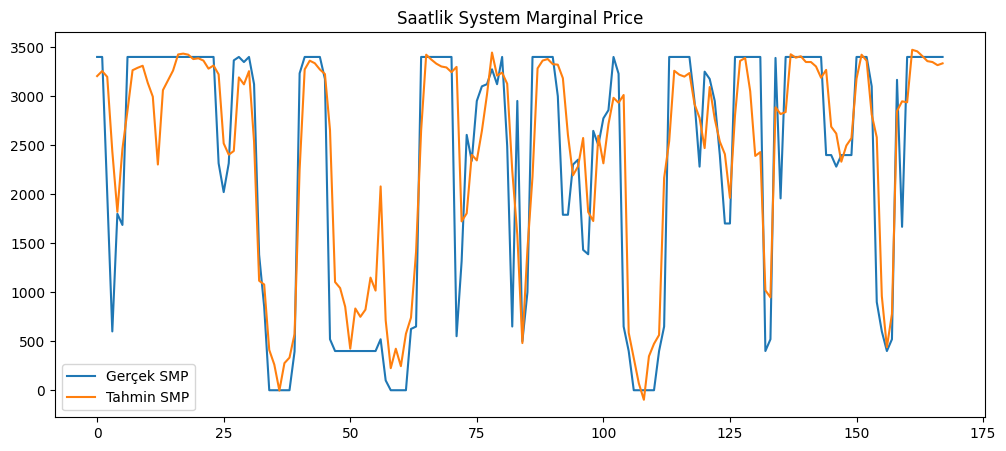

In [10]:
# =================================
# 8. SAATLİK GRAFİK
# =================================

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Gerçek SMP')
plt.plot(y_pred, label='Tahmin SMP')
plt.legend()
plt.title('Saatlik System Marginal Price')
plt.show()


In [11]:
# =================================
# 9. GÜNLÜK MAPE (SEKTÖR STANDARDI)
# =================================

results = pd.DataFrame({
    'date': test_df['date'].values,
    'actual': y_test.values,
    'predicted': y_pred
})

results['day'] = pd.to_datetime(results['date']).dt.date

daily = results.groupby('day').mean()

EPS = 1e-6
daily['MAPE'] = (
    np.abs(daily['actual'] - daily['predicted']) /
    np.maximum(daily['actual'], EPS)
) * 100

print(f"Ortalama Günlük MAPE: %{daily['MAPE'].mean():.2f}")


Ortalama Günlük MAPE: %6.37


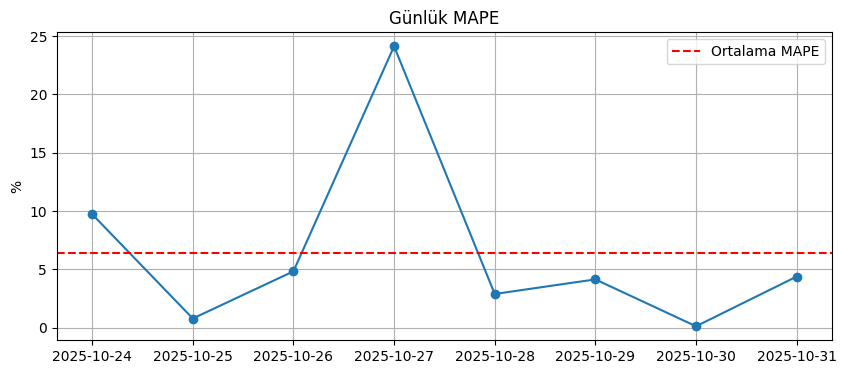

In [12]:
# =================================
# 10. GÜNLÜK MAPE GRAFİĞİ
# =================================

plt.figure(figsize=(10,4))
plt.plot(daily.index, daily['MAPE'], marker='o')
plt.axhline(
    daily['MAPE'].mean(),
    color='r',
    linestyle='--',
    label='Ortalama MAPE'
)
plt.legend()
plt.title('Günlük MAPE')
plt.ylabel('%')
plt.grid(True)
plt.show()


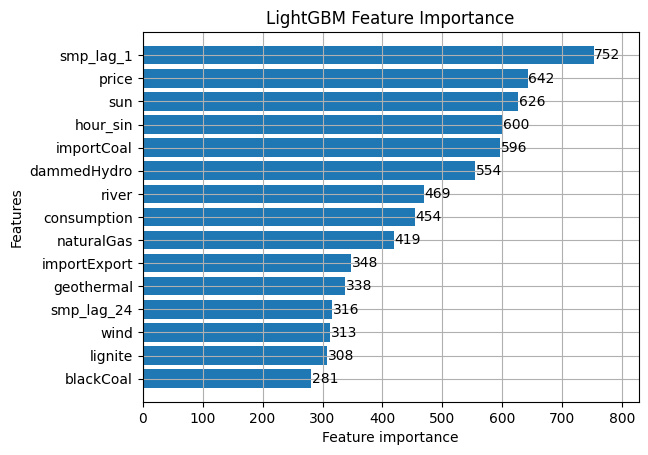

In [13]:
# =================================
# 11. FEATURE IMPORTANCE (Öznitelik/Özellik Önem Dereceleri)
# =================================

lgb.plot_importance(model, max_num_features=15, height=0.8)
plt.title('LightGBM Feature Importance')
plt.show()

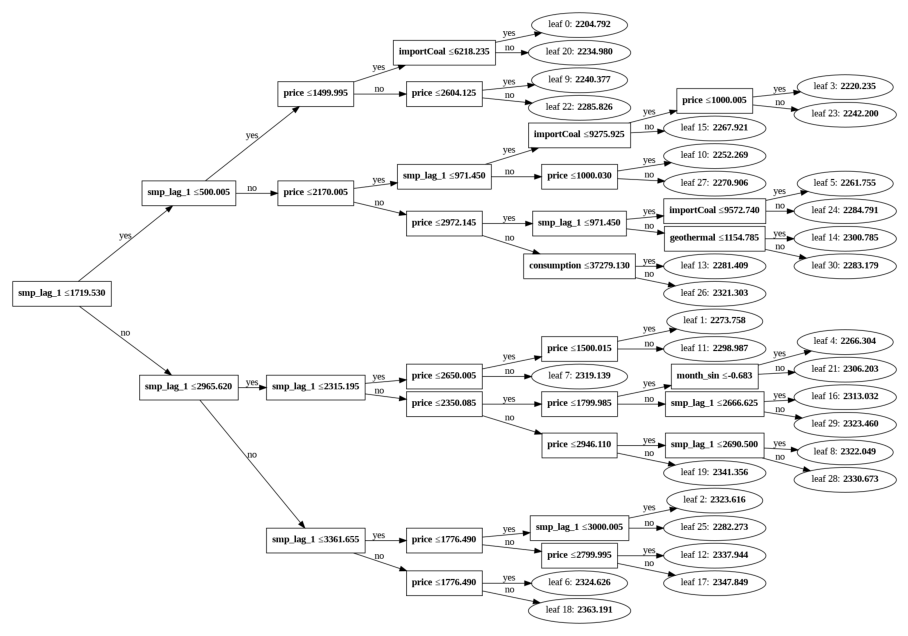

In [14]:
lgb.plot_tree(model, tree_index=0, figsize=(20, 8))
plt.show()